# 03 — E-Perf-6: per-node RSS scaling

RFC-008 §E-Perf-6. Renders per-depth steady-state RSS from the
`eval/scripts/run-e-perf-6-8-shakedown.sh` memory sampler (1 Hz `ps`).

**Inputs**: `eval/results/e-perf-6/<host-tag>-<ts>/depth-{1,3,5,10}/run-NN/memory.csv`

**Configure** with `SHAKEDOWN_DIR` env var; otherwise newest shakedown is used.

In [1]:
import json, os, sys, csv, statistics
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from wafer_analysis.paths import find_latest_shakedown

shakedown_dir = find_latest_shakedown('e-perf-6', pinned=os.environ.get('SHAKEDOWN_DIR'))
print(f'shakedown: {shakedown_dir}')

shakedown: <repo>/eval/results/e-perf-6/shakedown-macos-2026-07-22T17-49-56Z


In [2]:
# T9: apply thesis-grade matplotlib styling (font.family=serif, pdf.fonttype=42, mathtext=cm).
from wafer_analysis.plots import setup_thesis_style, save_figure
setup_thesis_style()


In [3]:
DEPTHS = [1, 3, 5, 10]

# Extract steady-state RSS per run (last N-1 samples = post-startup)
#
# Dual-schema parser (post-A19, 2026-08-02):
# - Pre-A19: `sample_ns,rss_kb,vsz_kb` from the ps-based external sampler.
# - Post-A19: `elapsed_ms,rss_bytes` from crates/wafer-core/src/bench/memory.rs
#   (memory_stats crate, in-process at 1Hz).
# The notebook picks the RSS column at parse time and normalises to bytes
# so downstream math is schema-agnostic.
def _read_rss_bytes(mem_csv):
    with open(mem_csv) as f:
        reader = csv.DictReader(f)
        fields = reader.fieldnames or []
        if 'rss_bytes' in fields:
            return [int(row['rss_bytes']) for row in reader]
        if 'rss_kb' in fields:
            return [int(row['rss_kb']) * 1024 for row in reader]
    raise RuntimeError(f'unknown memory.csv schema at {mem_csv}: fields={fields}')

rows = []
for depth in DEPTHS:
    depth_dir = shakedown_dir / f'depth-{depth}'
    for run_dir in sorted(depth_dir.glob('run-*')):
        mem_csv = run_dir / 'memory.csv'
        if not mem_csv.exists():
            continue
        samples = _read_rss_bytes(mem_csv)
        if len(samples) < 2:
            continue
        # Steady-state: last N-1 samples (skip startup spike)
        steady = samples[1:]
        rows.append({
            'depth': depth,
            'run': run_dir.name,
            'rss_bytes_median': statistics.median(steady),
            'rss_bytes_max': max(steady),
            'n_samples': len(samples),
        })

df = pd.DataFrame(rows)
summary = df.groupby('depth').agg(
    median_rss_bytes=('rss_bytes_median', 'median'),
    mean_rss_bytes=('rss_bytes_median', 'mean'),
    stdev_rss_bytes=('rss_bytes_median', 'std'),
    n=('rss_bytes_median', 'count'),
).reset_index()
summary['rss_mb'] = summary['median_rss_bytes'] / (1024 * 1024)
print(summary.to_string(index=False))


 depth  median_rss_bytes  mean_rss_bytes  stdev_rss_bytes  n    rss_mb
     1        36315136.0    3.640061e+07    548198.215786 30 34.632812
     3        40894464.0    4.093679e+07    811976.375767 30 39.000000
     5        42807296.0    4.297551e+07    693512.721409 30 40.824219
    10        47259648.0    4.741093e+07    694440.559527 30 45.070312


In [4]:
# Linear fit: RSS = intercept + slope * depth
from numpy.polynomial import polynomial as P

x = summary['depth'].values.astype(float)
y = summary['median_rss_bytes'].values.astype(float)

coeffs = np.polyfit(x, y, 1)  # [slope, intercept]
slope, intercept = coeffs
y_pred = np.polyval(coeffs, x)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_sq = 1 - ss_res / ss_tot

# slope/intercept are bytes; convert for readable log line.
print(f'RSS slope: {slope:.0f} bytes/hop ({slope / (1024 * 1024):.2f} MB/hop)')
print(f'Intercept: {intercept:.0f} bytes ({intercept / (1024 * 1024):.1f} MB)')
print(f'R²: {r_sq:.4f}')


RSS slope: 1141182 bytes/hop (1.09 MB/hop)
Intercept: 36398520 bytes (34.7 MB)
R²: 0.9442


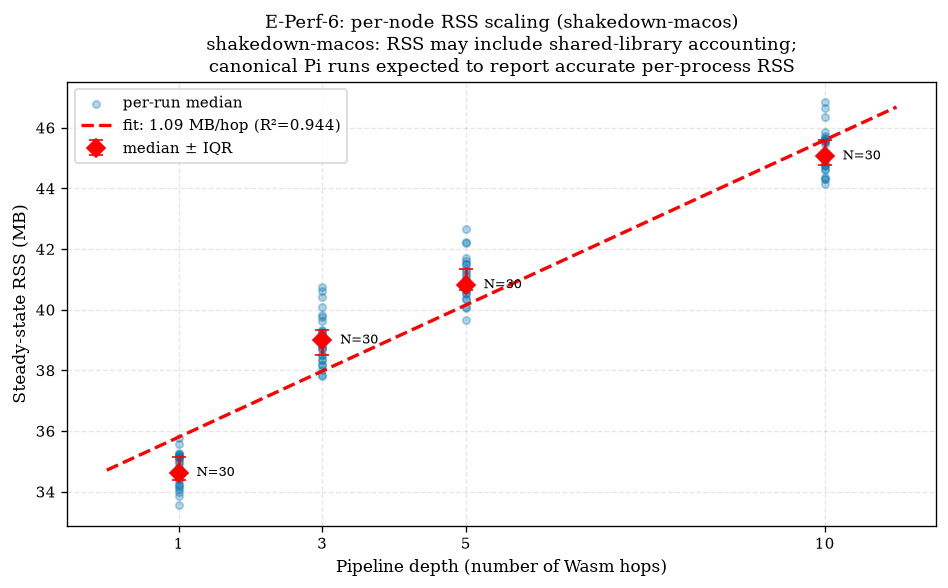

saved thesis figure to ../figures/e-perf-6/rss_scaling.pdf


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

# Scatter: per-run medians (bytes -> MB)
ax.scatter(df['depth'], df['rss_bytes_median'] / (1024 * 1024),
           alpha=0.3, s=20, label='per-run median', zorder=2)

# Linear fit
x_fit = np.linspace(0, 11, 50)
y_fit = (slope * x_fit + intercept) / (1024 * 1024)
ax.plot(x_fit, y_fit, 'r--', linewidth=2,
        label=f'fit: {slope / (1024 * 1024):.2f} MB/hop (R\u00b2={r_sq:.3f})')

# IQR error bars + N annotation per depth
iqr_df = df.groupby('depth').agg(
    med_mb  = ('rss_bytes_median', lambda x: np.median(x)     / (1024 * 1024)),
    q25_mb  = ('rss_bytes_median', lambda x: np.percentile(x, 25) / (1024 * 1024)),
    q75_mb  = ('rss_bytes_median', lambda x: np.percentile(x, 75) / (1024 * 1024)),
    n       = ('rss_bytes_median', 'count'),
).reset_index()

first = True
for _, row in iqr_df.iterrows():
    lbl = 'median \u00b1 IQR' if first else None
    first = False
    ax.errorbar(row['depth'], row['med_mb'],
                yerr=[[row['med_mb'] - row['q25_mb']],
                      [row['q75_mb'] - row['med_mb']]],
                fmt='D', color='red', markersize=8, capsize=4,
                elinewidth=1.5, label=lbl, zorder=5)
    ax.text(row['depth'] + 0.25, row['med_mb'],
            f'N={int(row["n"])}', fontsize=8, va='center')

ax.set_xlabel('Pipeline depth (number of Wasm hops)')
ax.set_ylabel('Steady-state RSS (MB)')
ax.set_title('E-Perf-6: per-node RSS scaling (shakedown-macos)\n'
             'shakedown-macos: RSS may include shared-library accounting;\n'
             'canonical Pi runs expected to report accurate per-process RSS')
ax.legend()
ax.set_xticks(DEPTHS)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# T9: persist thesis figure to ../figures/e-perf-6/rss_scaling.{pdf,png}
_saved = save_figure(fig, 'e-perf-6/rss_scaling')
print(f'saved thesis figure to {_saved}')

## Interpretation

The slope represents the per-Wasm-node RSS cost: each additional pass-through
transform adds ~1 MB of steady-state RSS. The intercept (~35 MB) is the
fixed runtime overhead (wasmtime engine, tokio runtime, channels, bench
source/sink).

**macOS caveat**: `ps` RSS on macOS includes shared libraries and
memory-mapped regions that would be shared across processes on Linux.
Pi canonical numbers will use `/proc/<pid>/smaps_rollup` for accurate
RSS (Rss - Shared_Clean - Shared_Dirty = private RSS).